## 1. Import Libraries

In [ ]:
import pandas as pd

import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc

from sklearn.model_selection import GridSearchCV

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image
import io
from PIL import Image as PILI

## 2. Load Datasets

In [2]:
from google.colab import files
# Prompt user to upload classificaata.csv
print("Upload classification_data.csv ")
uploaded = files.upload()
# Load the classification dataset
df_classification = pd.read_csv('classification_data.csv')
# Display the first 5 rows of  dataset to verify loading
print("Classification Dataset Preview:\n", df_classification.head())

Upload classification_data.csv 


Saving classification_data.csv to classification_data.csv
Classification Dataset Preview:
         Age     Grade  Tumor_Size  Regional_Node_Examined  \
0  1.550325  1.330387   -1.253980                1.184029   
1 -0.443977 -0.236080    0.215056               -0.046389   
2  0.442379 -0.236080    1.541927               -0.046389   
3  0.442379  1.330387   -0.590544               -1.522891   
4 -0.776361  1.330387    0.499386               -1.399849   

   Reginol_Node_Positive  Mortality_Status  Sex_Female  T_Stage_T2  \
0              -0.618426                 1        True       False   
1               0.164352                 1        True        True   
2               0.555742                 1        True       False   
3              -0.618426                 1        True       False   
4              -0.618426                 1        True        True   

   T_Stage_T3  T_Stage_T4  ...  6th_Stage_IIB  6th_Stage_IIIA  6th_Stage_IIIB  \
0       False       False  ...          

# Data understanding

In [3]:
print(df_classification.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4021 entries, 0 to 4020
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age                                   4021 non-null   float64
 1   Grade                                 4021 non-null   float64
 2   Tumor_Size                            4021 non-null   float64
 3   Regional_Node_Examined                4021 non-null   float64
 4   Reginol_Node_Positive                 4021 non-null   float64
 5   Mortality_Status                      4021 non-null   int64  
 6   Sex_Female                            4021 non-null   bool   
 7   T_Stage_T2                            4021 non-null   bool   
 8   T_Stage_T3                            4021 non-null   bool   
 9   T_Stage_T4                            4021 non-null   bool   
 10  N_Stage_N2                            4021 non-null   bool   
 11  N_Stage_N3       

In [4]:
# Prompt user to upload regression_data.csv
print("Upload regression_data.csv")
uploaded = files.upload()
# Load the regression dataset
df_regression = pd.read_csv('regression_data.csv')
# Display the first 5 rows of  dataset to verify loading
print("Regression Dataset Preview:\n", df_regression.head())


Upload regression_data.csv


Saving regression_data.csv to regression_data.csv
Regression Dataset Preview:
         Age     Grade  Tumor_Size  Regional_Node_Examined  \
0 -1.551923 -0.236080   -0.021885               -0.661598   
1  0.331585 -0.236080    1.873645               -0.292473   
2 -1.330334 -0.236080   -1.017038                0.076652   
3  1.439530 -0.236080   -0.827485                0.199694   
4 -2.549074  1.330387    1.873645                1.060987   

   Reginol_Node_Positive  Survival_Months  Sex_Female  T_Stage_T2  T_Stage_T3  \
0              -0.618426               14        True        True       False   
1               1.534215               42        True       False        True   
2              -0.422732               39        True       False       False   
3              -0.227037               60        True       False       False   
4               3.686855               44        True       False        True   

   T_Stage_T4  ...  6th_Stage_IIB  6th_Stage_IIIA  6th_Stage_IIIB  

In [5]:
print(df_regression.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age                                   615 non-null    float64
 1   Grade                                 615 non-null    float64
 2   Tumor_Size                            615 non-null    float64
 3   Regional_Node_Examined                615 non-null    float64
 4   Reginol_Node_Positive                 615 non-null    float64
 5   Survival_Months                       615 non-null    int64  
 6   Sex_Female                            615 non-null    bool   
 7   T_Stage_T2                            615 non-null    bool   
 8   T_Stage_T3                            615 non-null    bool   
 9   T_Stage_T4                            615 non-null    bool   
 10  N_Stage_N2                            615 non-null    bool   
 11  N_Stage_N3         

In [6]:
# Shape of the filtered dataset
print(df_regression.shape)

# Feature names used for regression
print(df_regression.columns)

(615, 22)
Index(['Age', 'Grade', 'Tumor_Size', 'Regional_Node_Examined',
       'Reginol_Node_Positive', 'Survival_Months', 'Sex_Female', 'T_Stage_T2',
       'T_Stage_T3', 'T_Stage_T4', 'N_Stage_N2', 'N_Stage_N3', '6th_Stage_IIB',
       '6th_Stage_IIIA', '6th_Stage_IIIB', '6th_Stage_IIIC',
       'Differentiated_Poorly differentiated',
       'Differentiated_Undifferentiated', 'Differentiated_Well differentiated',
       'A_Stage_Regional', 'Estrogen_Status_Positive',
       'Progesterone_Status_Positive'],
      dtype='object')


## 5. Define Input Features and Targets

**Classification Dataset**

In [7]:
if len(df_classification) > 0 and 'Mortality_Status' in df_classification.columns:
    # Define input features and target
    X = df_classification.drop(columns=['Mortality_Status'])
    y = df_classification['Mortality_Status']
    # Display shapes to verify
    print("Classification Input Features Shape:", X.shape)
    print("Classification Target Shape:", y.shape)
else:
    print("Classification Dataset is empty or missing 'Mortality_Status'. Cannot declare features.")

Classification Input Features Shape: (4021, 21)
Classification Target Shape: (4021,)


## 6. Split Data into Training and Testing Sets

In [8]:
# Set random seed for reproducibility
# Classification: Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 , stratify=y )

# Display shapes of training and testing sets
print('Classification Training Features Shape:', X_train.shape)
print('Classification Training Target Shape:', y_train.shape)
print('Classification Testing Features Shape:', X_test.shape)
print('Classification Testing Target Shape:', y_test.shape)

Classification Training Features Shape: (3216, 21)
Classification Training Target Shape: (3216,)
Classification Testing Features Shape: (805, 21)
Classification Testing Target Shape: (805,)


# Build and Train Voting Classifier with Logistic Regression + KNN

In [9]:
# Create individual models
log_reg = LogisticRegression(max_iter=1000, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

# Create Voting Classifier (hard voting)
voting_clf = VotingClassifier(
    estimators=[('lr', log_reg), ('knn', knn)],
    voting='soft')

# Train the ensemble model
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42)),
                             ('knn', KNeighborsClassifier())],
                 voting='soft')

# Evaluate Classification Performance

Accuracy: 0.8521739130434782

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.13      0.21       123
           1       0.86      0.98      0.92       682

    accuracy                           0.85       805
   macro avg       0.72      0.56      0.57       805
weighted avg       0.82      0.85      0.81       805



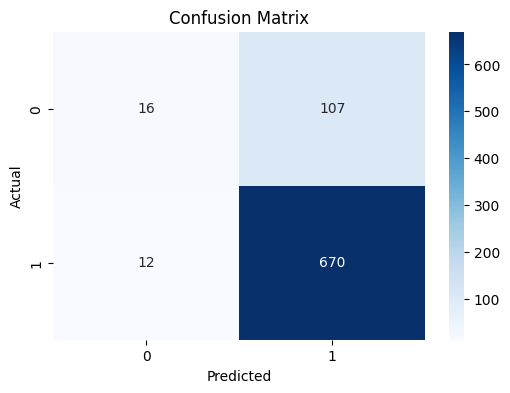

ROC Curve for binary classification


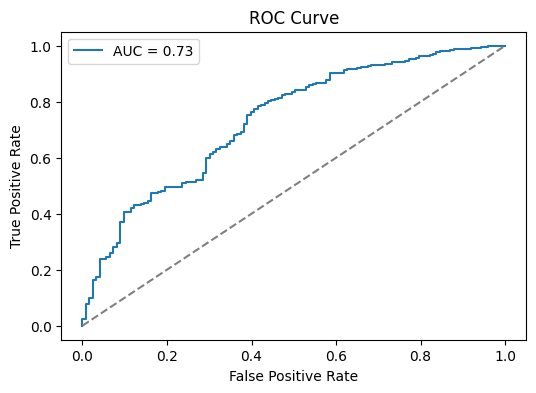

In [10]:
# Predict on test set
y_pred = voting_clf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve (for binary classification)
print("ROC Curve for binary classification")
y_proba = voting_clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

#Display confution Matrix
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

**Regression Dataset**

In [11]:
# Regression: Define input features (all columns except Survival_Months)
X_reg = df_regression.drop('Survival_Months', axis=1)
# Regression: Define target variable (Survival_Months)
y_reg = df_regression['Survival_Months']
# Display shapes of input features and targets
print('Regression Input Features Shape:', X_reg.shape)
print('Regression Target Shape:', y_reg.shape)

Regression Input Features Shape: (615, 21)
Regression Target Shape: (615,)


# Split Data into Training and Testing Sets

In [12]:
# Regression: Split data into 80% training and 20% testing
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
# Display shapes of training and testing sets
print('Regression Training Features Shape:', X_reg_train.shape)
print('Regression Training Target Shape:', y_reg_train.shape)
print('Regression Testing Features Shape:', X_reg_test.shape)
print('Regression Testing Target Shape:', y_reg_test.shape)

Regression Training Features Shape: (492, 21)
Regression Training Target Shape: (492,)
Regression Testing Features Shape: (123, 21)
Regression Testing Target Shape: (123,)


## Create Fully Grown DT - 1

In [13]:
from sklearn import metrics
from sklearn import tree
# Create and train a fully-grown Decision Tree Regressor
DT_reg = DecisionTreeRegressor()
DT_reg.fit(X_reg_train, y_reg_train)

# Predict on test data
yr_pred = DT_reg.predict(X_reg_test)

# Evaluate performance of the pruned model
print("Evaluation of Fully grown Decision Tree Regressor:")
print("------------------------------------------------")
print("Mean Absolute Error (MAE):", metrics.mean_absolute_error(y_reg_test, yr_pred))
print("Mean Squared Error (MSE):", metrics.mean_squared_error(y_reg_test, yr_pred))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_reg_test, yr_pred)))
print("R² Score:", metrics.r2_score(y_reg_test, yr_pred))



Evaluation of Fully grown Decision Tree Regressor:
------------------------------------------------
Mean Absolute Error (MAE): 28.910569105691057
Mean Squared Error (MSE): 1287.121951219512
Root Mean Squared Error (RMSE): 35.876481867924454
R² Score: -1.2561083217397022


In [ ]:
from google.colab import files
#Disply Fully grown DT-1
DT_Tree_figure = plt.figure(figsize=(200,200))
DT_Graph = tree.plot_tree(DT_reg, feature_names=list(X_train.columns), filled=True)
# save fully grown DT-1
DT_Tree_figure.savefig("Full_decistion_tree.png" , dpi=300)
files.download("Full_decistion_tree.png")

# run the code so see Fully grown DT-2


# Cretate Pruned DT - 2

Evaluation of Pruned Decision Tree Regressor:
------------------------------------------------
Mean Absolute Error (MAE): 19.65240380114112
Mean Squared Error (MSE): 592.9940958730344
Root Mean Squared Error (RMSE): 24.351470096752568
R² Score: -0.03941892465906571


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

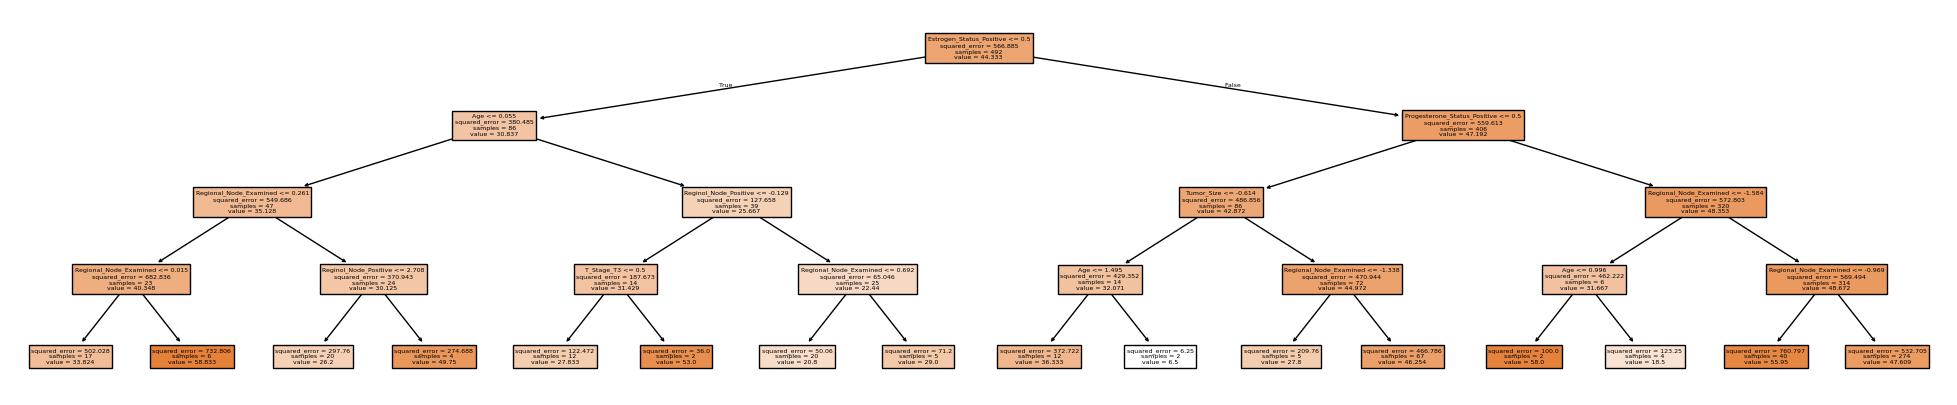

In [14]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics
from sklearn import tree

# Prune the decision tree using max_depth
DT_pruned = DecisionTreeRegressor(max_depth=4, random_state=42)
DT_pruned.fit(X_reg_train, y_reg_train)

# Predict on the test set
y_pred_pruned = DT_pruned.predict(X_reg_test)

# Evaluate performance of the pruned model
print("Evaluation of Pruned Decision Tree Regressor:")
print("------------------------------------------------")
print("Mean Absolute Error (MAE):", mean_absolute_error(y_reg_test, y_pred_pruned))
print("Mean Squared Error (MSE):", mean_squared_error(y_reg_test, y_pred_pruned))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_reg_test, y_pred_pruned)))
print("R² Score:", r2_score(y_reg_test, y_pred_pruned))

# print pruned Tree
Tree_figure = plt.figure(figsize=(25,5))
Tree_Graph = tree.plot_tree(DT_pruned, feature_names=list(X_train.columns), filled=True)

# save pruned Tree
Tree_figure.savefig("decistion_tree.png" , dpi=300)
from google.colab import files
files.download("decistion_tree.png")
